In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout, Input, TimeDistributed
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# Download and unzip the UCI HAR dataset
!wget -q https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
!unzip -q -o "human+activity+recognition+using+smartphones.zip"
!unzip -q -o "UCI HAR Dataset.zip"


In [ ]:
def load_har_data(data_type='train'):
    path = f'UCI HAR Dataset/{data_type}/Inertial Signals/'
    signals = [
        'body_acc_x_', 'body_acc_y_', 'body_acc_z_',
        'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_',
        'total_acc_x_', 'total_acc_y_', 'total_acc_z_'
    ]
    loaded_signals = []
    for signal in signals:
        filename = f'{path}{signal}{data_type}.txt'
        data = pd.read_csv(filename, delim_whitespace=True, header=None).values
        loaded_signals.append(data)

    # Stack along the channel axis to get shape (N, 128, 9)
    X = np.dstack(loaded_signals)
    y = pd.read_csv(f'UCI HAR Dataset/{data_type}/y_{data_type}.txt', delim_whitespace=True, header=None).values
    return X, y

X_train_raw, y_train_raw = load_har_data('train')
X_test_raw, y_test_raw = load_har_data('test')

# Combine to create our own custom splits (and take a subset for execution speed)
X_full = np.concatenate((X_train_raw, X_test_raw), axis=0)
y_full = np.concatenate((y_train_raw, y_test_raw), axis=0)

# The manual recommends using 1500-3000 samples to keep training fast
SUBSET_SIZE = 3000
X_sub = X_full[:SUBSET_SIZE]
y_sub = y_full[:SUBSET_SIZE].flatten() - 1 # 0-index the labels (0 to 5)

activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

# 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X_sub, y_sub, test_size=0.3, random_state=42, stratify=y_sub)
# Split Temp into 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Normalize using training statistics (flatten to 2D for scaler, then reshape back)
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)

X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

print("Input tensor shape:")
print(f"Training   : {X_train_scaled.shape}")
print(f"Validation : {X_val_scaled.shape}")
print(f"Testing    : {X_test_scaled.shape}")


/tmp/ipykernel_1117/3567596262.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None).values
/tmp/ipykernel_1117/3567596262.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None).values
/tmp/ipykernel_1117/3567596262.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None).values
/tmp/ipykernel_1117/3567596262.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, head

Input tensor shape:
Training   : (2100, 128, 9)
Validation : (450, 128, 9)
Testing    : (450, 128, 9)


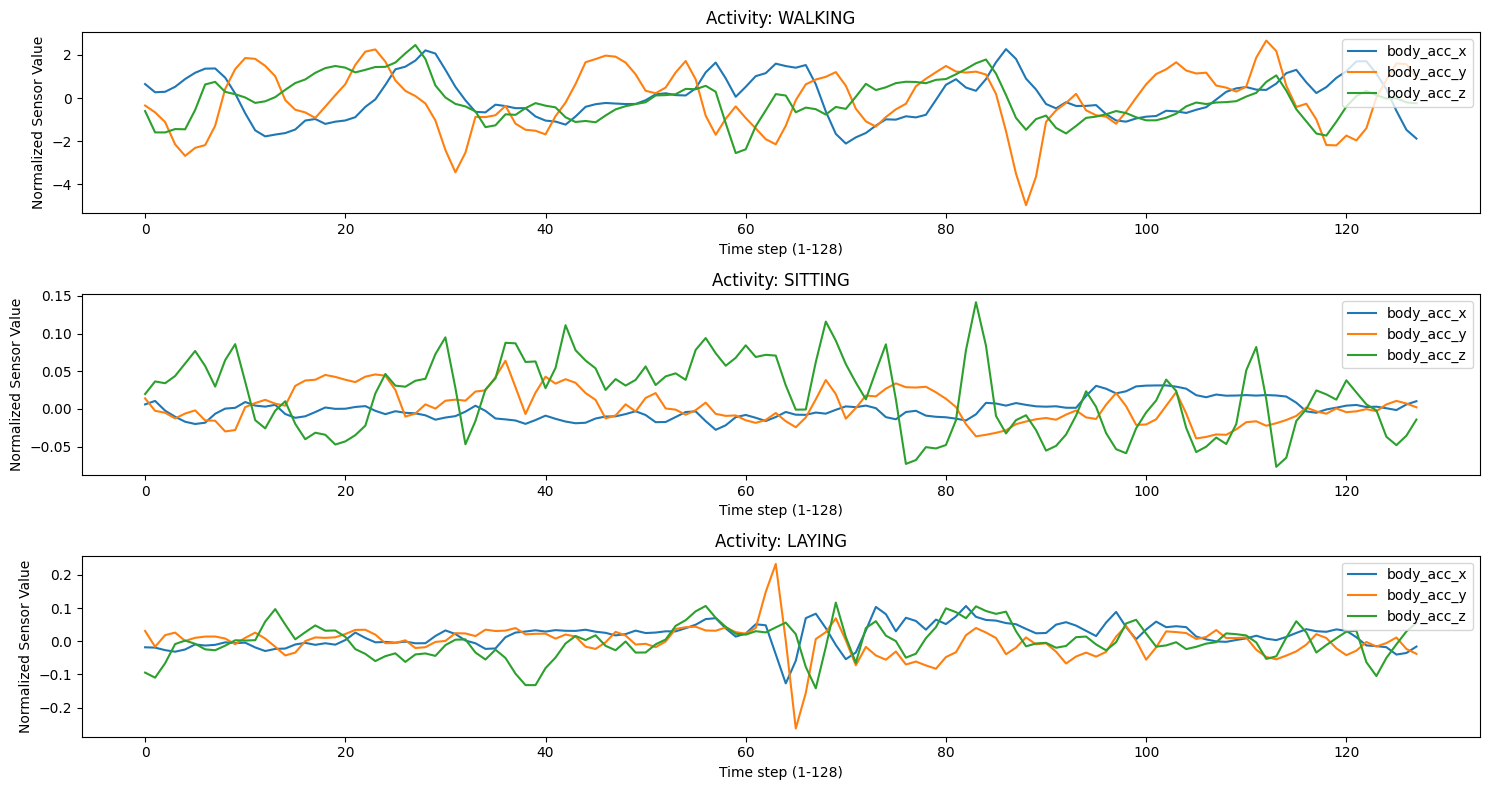

In [ ]:
plt.figure(figsize=(15, 8))
classes_to_plot = [0, 3, 5] # WALKING, SITTING, LAYING

for i, cls in enumerate(classes_to_plot):
    plt.subplot(3, 1, i+1)
    idx = np.where(y_train == cls)[0][0] # First instance of the class
    sample = X_train_scaled[idx]

    # Plot body_acc (x, y, z channels)
    plt.plot(sample[:, 0], label='body_acc_x')
    plt.plot(sample[:, 1], label='body_acc_y')
    plt.plot(sample[:, 2], label='body_acc_z')
    plt.title(f'Activity: {activities[cls]}')
    plt.xlabel('Time step (1-128)')
    plt.ylabel('Normalized Sensor Value')
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
x1, x2, x3 = 0.5, 0.7, 0.2
h0 = 0
Wx, Wh, b = 0.5, 0.8, 0.1

def rnn_step(x, h_prev):
    return np.tanh(Wx * x + Wh * h_prev + b)

h1 = rnn_step(x1, h0)
h2 = rnn_step(x2, h1)
h3 = rnn_step(x3, h2)

print(f"h1: {h1:.4f}")
print(f"h2: {h2:.4f}")
print(f"h3: {h3:.4f}")


h1: 0.3364
h2: 0.6164
h3: 0.6000


In [ ]:
def create_model(rnn_layer_type='RNN'):
    model = Sequential()
    model.add(Input(shape=(128, 9)))

    if rnn_layer_type == 'RNN':
        model.add(SimpleRNN(32))
    elif rnn_layer_type == 'LSTM':
        model.add(LSTM(32))
    elif rnn_layer_type == 'GRU':
        model.add(GRU(32))

    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(6, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

epochs = 30
batch_size = 32

models = {'RNN': None, 'LSTM': None, 'GRU': None}
histories = {}
train_times = {}

for name in models.keys():
    print(f"\n--- Training {name} ---")
    model = create_model(name)
    start_time = time.time()

    history = model.fit(X_train_scaled, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val_scaled, y_val),
                        verbose=1) # Set verbose=0 if you want to hide epoch progress

    train_times[name] = time.time() - start_time
    models[name] = model
    histories[name] = history.history



--- Training RNN ---
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4057 - loss: 1.5047 - val_accuracy: 0.5911 - val_loss: 1.1525
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6067 - loss: 1.0308 - val_accuracy: 0.6600 - val_loss: 0.8818
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6657 - loss: 0.8281 - val_accuracy: 0.6867 - val_loss: 0.7247
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6919 - loss: 0.6999 - val_accuracy: 0.7200 - val_loss: 0.6599
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7057 - loss: 0.6470 - val_accuracy: 0.7267 - val_loss: 0.6224
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7210 - loss: 0.6024 - val_accuracy: 0.7333 - val_loss: 0.5886
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7286 - loss: 0.5858 - val_accuracy: 0.7422 - val_loss: 0.5902
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7419 - loss: 0.5680 - va

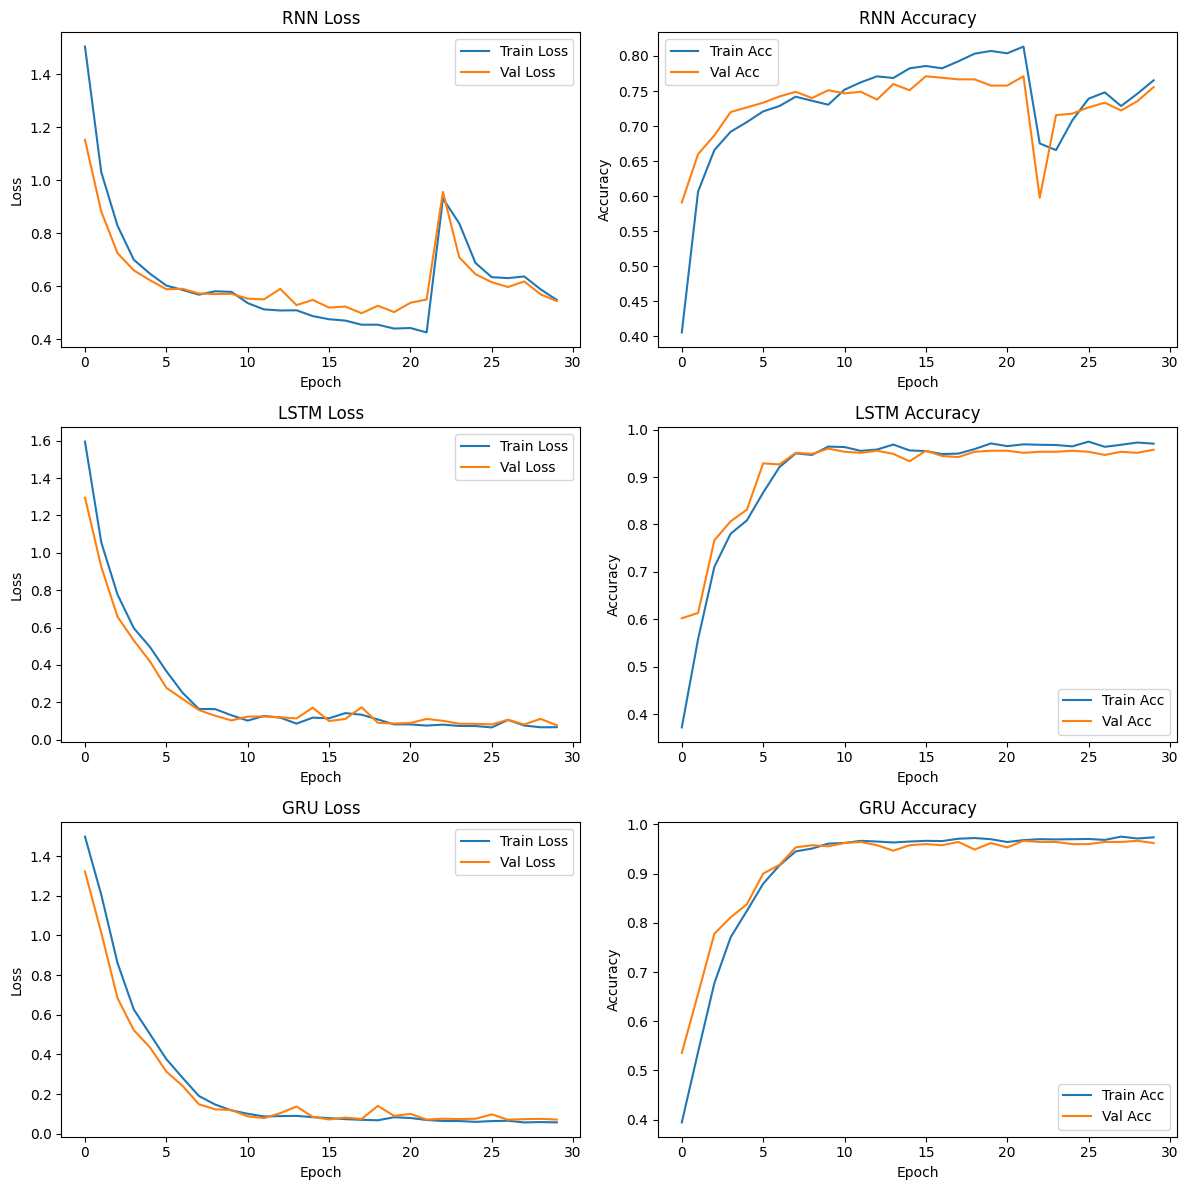

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, name in enumerate(['RNN', 'LSTM', 'GRU']):
    hist = histories[name]

    # Loss
    axes[i, 0].plot(hist['loss'], label='Train Loss')
    axes[i, 0].plot(hist['val_loss'], label='Val Loss')
    axes[i, 0].set_title(f'{name} Loss')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()

    # Accuracy
    axes[i, 1].plot(hist['accuracy'], label='Train Acc')
    axes[i, 1].plot(hist['val_accuracy'], label='Val Acc')
    axes[i, 1].set_title(f'{name} Accuracy')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,74.666667,74.642485,73.518478,73.557222,1974,28.935778
1,LSTM,95.555556,95.694668,95.712234,95.640739,6006,24.045370
2,GRU,96.666667,96.705084,96.752832,96.727510,4758,25.033629


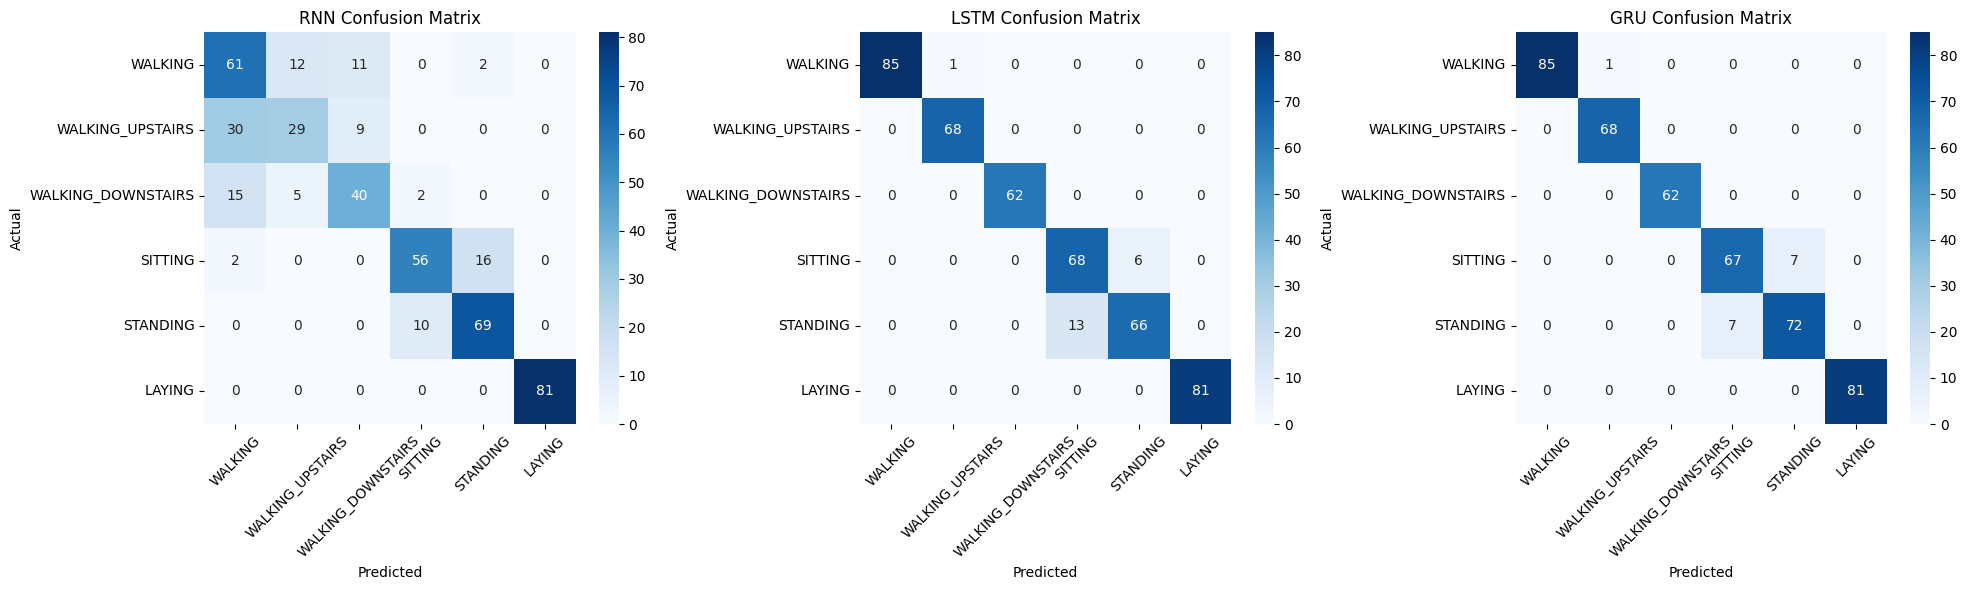

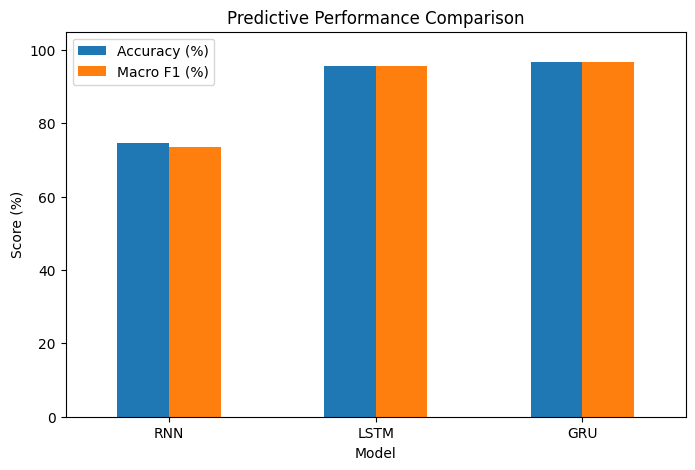

In [ ]:
results = []
confusion_matrices = {}

for name in ['RNN', 'LSTM', 'GRU']:
    model = models[name]

    # Predictions
    y_pred_prob = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    params = model.count_params()

    results.append({
        'Model': name,
        'Accuracy (%)': acc * 100,
        'Macro Precision (%)': prec * 100,
        'Macro Recall (%)': rec * 100,
        'Macro F1 (%)': f1 * 100,
        'Parameters': params,
        'Training Time (s)': train_times[name]
    })

    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results)
display(results_df)

# Plot 4: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, name in enumerate(['RNN', 'LSTM', 'GRU']):
    sns.heatmap(confusion_matrices[name], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=activities, yticklabels=activities)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Plot 5: Model Performance Comparison Bar Chart
results_df.set_index('Model')[['Accuracy (%)', 'Macro F1 (%)']].plot(kind='bar', figsize=(8, 5))
plt.title('Predictive Performance Comparison')
plt.ylabel('Score (%)')
plt.ylim(0, 105)
plt.xticks(rotation=0)
plt.show()



Testing Sequence Length: 32

Testing Sequence Length: 64

Testing Sequence Length: 128


,RNN F1,LSTM F1,GRU F1
32,72.023965,93.306148,84.156484
64,72.483480,94.141991,94.154115
128,67.500208,96.731468,95.198990


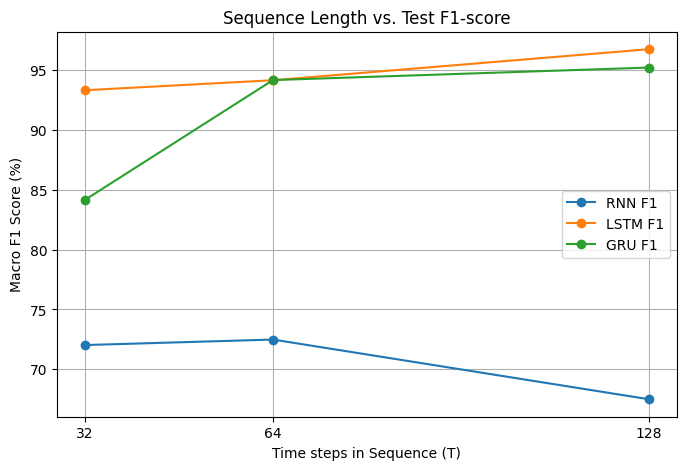

In [ ]:
seq_lengths = [32, 64, 128]
seq_results = {32: {}, 64: {}, 128: {}}

for seq_len in seq_lengths:
    print(f"\nTesting Sequence Length: {seq_len}")

    # Truncate sequences
    X_tr = X_train_scaled[:, :seq_len, :]
    X_v = X_val_scaled[:, :seq_len, :]
    X_te = X_test_scaled[:, :seq_len, :]

    for name in ['RNN', 'LSTM', 'GRU']:
        model = Sequential()
        model.add(Input(shape=(seq_len, 9)))

        if name == 'RNN': model.add(SimpleRNN(32))
        elif name == 'LSTM': model.add(LSTM(32))
        elif name == 'GRU': model.add(GRU(32))

        model.add(Dropout(0.2))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(6, activation='softmax'))

        model.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        model.fit(X_tr, y_train, epochs=10, batch_size=32, verbose=0) # Only 10 epochs to run fast

        y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

        seq_results[seq_len][f"{name} F1"] = f1 * 100

seq_df = pd.DataFrame(seq_results).T
display(seq_df)

# Plot 6: Sequence Length vs Test F1-score
seq_df.plot(kind='line', marker='o', figsize=(8, 5))
plt.title('Sequence Length vs. Test F1-score')
plt.xlabel('Time steps in Sequence (T)')
plt.ylabel('Macro F1 Score (%)')
plt.xticks(seq_lengths)
plt.grid(True)
plt.show()


In [ ]:
import cv2
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input, TimeDistributed
from tensorflow.keras.applications import MobileNetV2

# 1. Download and Extract the UCF101 Dataset
# Warning: This is a ~6.5GB file. It will take a few minutes in Colab!
print("Downloading UCF101 Dataset...")
!wget -q --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
print("Extracting UCF101 Dataset...")
!unrar x -inul UCF101.rar

# 2. Extract Frames using OpenCV
classes = ['Basketball', 'Biking', 'Walking']
videos_per_class = 5
num_frames = 10
img_size = (224, 224)

X_videos = []
y_videos = []

print("Extracting frames from videos...")
for label, cls in enumerate(classes):
    # Find all .avi videos for this specific class
    video_paths = glob.glob(f'UCF-101/{cls}/*.avi')[:videos_per_class]

    for path in video_paths:
        frames = []
        cap = cv2.VideoCapture(path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Sample frames uniformly across the video
        if total_frames > 0:
            step = max(total_frames // num_frames, 1)
            frame_indices = [i * step for i in range(num_frames)]

            for idx in frame_indices:
                if len(frames) >= num_frames:
                    break
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if ret:
                    # Resize to 224x224 and convert BGR to RGB
                    frame = cv2.resize(frame, img_size)
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    # Normalize pixel values to [0, 1]
                    frame = frame / 255.0
                    frames.append(frame)
        cap.release()

        # Pad with black frames if the video was too short
        while len(frames) < num_frames:
            frames.append(np.zeros((img_size[0], img_size[1], 3)))

        X_videos.append(np.array(frames))
        y_videos.append(label)

videos = np.array(X_videos, dtype='float32')
video_labels = np.array(y_videos)

print(f"Final Video Tensor Shape: {videos.shape}") # Should be (15, 10, 224, 224, 3)

# 3. Build the CNN-LSTM Pipeline
# Pretrained CNN Feature Extractor
cnn_base = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
cnn_base.trainable = False

print("Required Observation 1: CNN Feature Dimension (D) =", cnn_base.output_shape[-1])

# Full Pipeline Setup
video_input = Input(shape=(num_frames, 224, 224, 3))
encoded_frames = TimeDistributed(cnn_base)(video_input)

print("Required Observation 2: Tensor shape supplied to recurrent network =", encoded_frames.shape)

x = LSTM(32)(encoded_frames)
x = Dense(len(classes), activation='softmax')(x)

video_model = Model(inputs=video_input, outputs=x)
video_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Train the Model
print("\n--- Training Video Understanding Model (Real UCF101 Data) ---")
# Using a small batch size since we only have 15 videos in this subset
video_history = video_model.fit(videos, video_labels, epochs=10, batch_size=4, validation_split=0.2, verbose=1)
video_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Required Observation 1: CNN Feature Dimension (D) = 1280
Required Observation 2: Tensor shape supplied to recurrent network = (None, 10, 1280)

--- Training Video Understanding Model (Dummy Data) ---
Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 64s 64s/step - accuracy: 0.1875 - loss: 1.8351 - val_accuracy: 0.2500 - val_loss: 1.4407
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.1875 - loss: 1.7079 - val_accuracy: 0.2500 - val_loss: 1.5599
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.1875 - loss: 1.6322 - val_accuracy: 0.2500 - val_loss: 1.6776
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.1875 - loss: 1.5921 - val_accuracy: 0.0000e+00 - val_loss: 1.7462
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.2500 - loss: 1.5824 - val_accuracy: 0.0000e+00 - val_loss: 1.7710


Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 10, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,762,673 (10.54 MB)

 Trainable params: 168,229 (657.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 336,460 (1.28 MB)

In [ ]:
seq_length = 4
vocab_size = 10
num_samples = 5000

# Synthetic dataset: Reversing sequences (e.g. [1, 4, 7, 2] -> [2, 7, 4, 1])
X_seq = np.random.randint(1, vocab_size, size=(num_samples, seq_length))
y_seq = np.fliplr(X_seq)

# Prepare decoder input for Teacher Forcing (shift target sequence right and add START token (0))
decoder_input = np.zeros((num_samples, seq_length))
decoder_input[:, 0] = 0 # START
decoder_input[:, 1:] = y_seq[:, :-1]

# One-hot encode for training
X_seq_oh = tf.keras.utils.to_categorical(X_seq, num_classes=vocab_size)
decoder_input_oh = tf.keras.utils.to_categorical(decoder_input, num_classes=vocab_size)
y_seq_oh = tf.keras.utils.to_categorical(y_seq, num_classes=vocab_size)

# --- Define Architecture ---
# Encoder
encoder_inputs = Input(shape=(seq_length, vocab_size))
encoder_lstm = LSTM(64, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(seq_length, vocab_size))
decoder_lstm = LSTM(64, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

seq2seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Training Seq2Seq Encoder-Decoder ---")
seq2seq_model.fit([X_seq_oh, decoder_input_oh], y_seq_oh, epochs=20, batch_size=64, validation_split=0.2, verbose=1)

# --- Inference ---
y_pred = seq2seq_model.predict([X_seq_oh, decoder_input_oh])
y_pred_classes = np.argmax(y_pred, axis=-1)

print("\n--- 5 Output Examples ---")
for i in range(5):
    print(f"Sample {i+1}: Input {X_seq[i]} -> Output {y_pred_classes[i]}")

# --- Evaluation Metrics ---
correct_tokens = np.sum(y_pred_classes == y_seq)
total_tokens = y_seq.size
token_acc = correct_tokens / total_tokens

# A sequence is fully correct only if all its elements match
correct_sequences = np.sum(np.all(y_pred_classes == y_seq, axis=1))
total_sequences = y_seq.shape[0]
sequence_acc = correct_sequences / total_sequences

print(f"\nToken Accuracy    : {token_acc*100:.2f}%")
print(f"Sequence Accuracy : {sequence_acc*100:.2f}%")



--- Training Seq2Seq Encoder-Decoder ---
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2981 - loss: 2.1104 - val_accuracy: 0.3785 - val_loss: 1.7010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4239 - loss: 1.4021 - val_accuracy: 0.4675 - val_loss: 1.2184
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5559 - loss: 1.0723 - val_accuracy: 0.6740 - val_loss: 0.9147
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7856 - loss: 0.7547 - val_accuracy: 0.8700 - val_loss: 0.6022
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9197 - loss: 0.4725 - val_accuracy: 0.9572 - val_loss: 0.3626
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9741 - loss: 0.2888 - val_accuracy: 0.9890 - val_loss: 0.2276
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9935 - loss: 0.1857 - val_accuracy: 0.9977 - val_loss: 0.1527
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9986 - loss

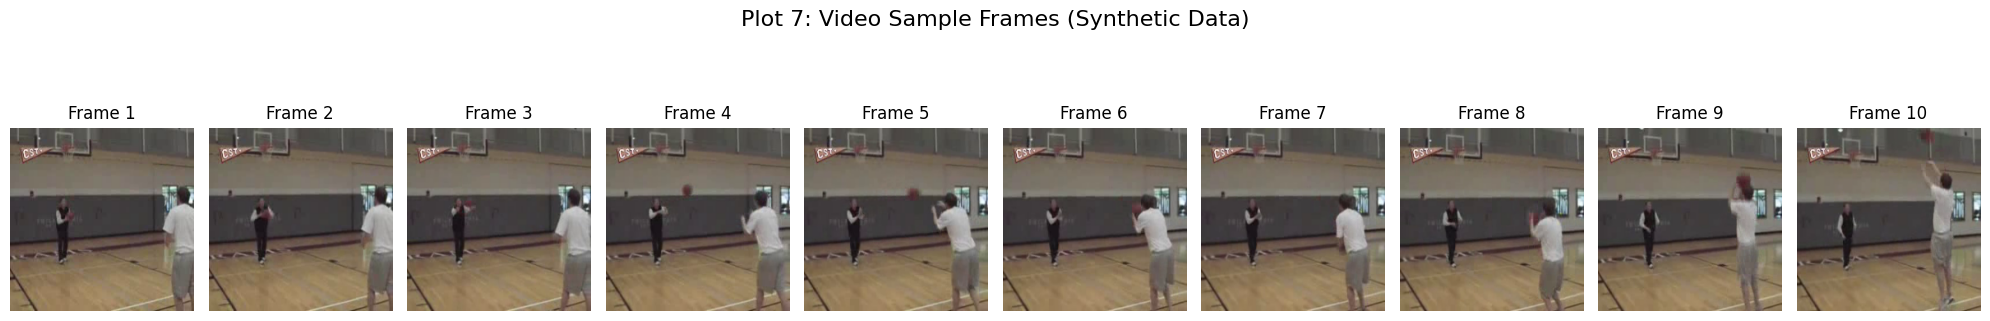

In [ ]:
# Plot 7: Video Sample Frames
# Taking the first video from our 'dummy' dataset
sample_video = videos[0]

plt.figure(figsize=(20, 4))
for i in range(num_frames):
    plt.subplot(1, num_frames, i + 1)
    # The dummy data is between 0 and 1, which imshow can plot directly
    plt.imshow(sample_video[i])
    plt.title(f"Frame {i+1}")
    plt.axis('off')

plt.suptitle("Plot 7: Video Sample Frames (Synthetic Data)", fontsize=16)
plt.tight_layout()
plt.show()


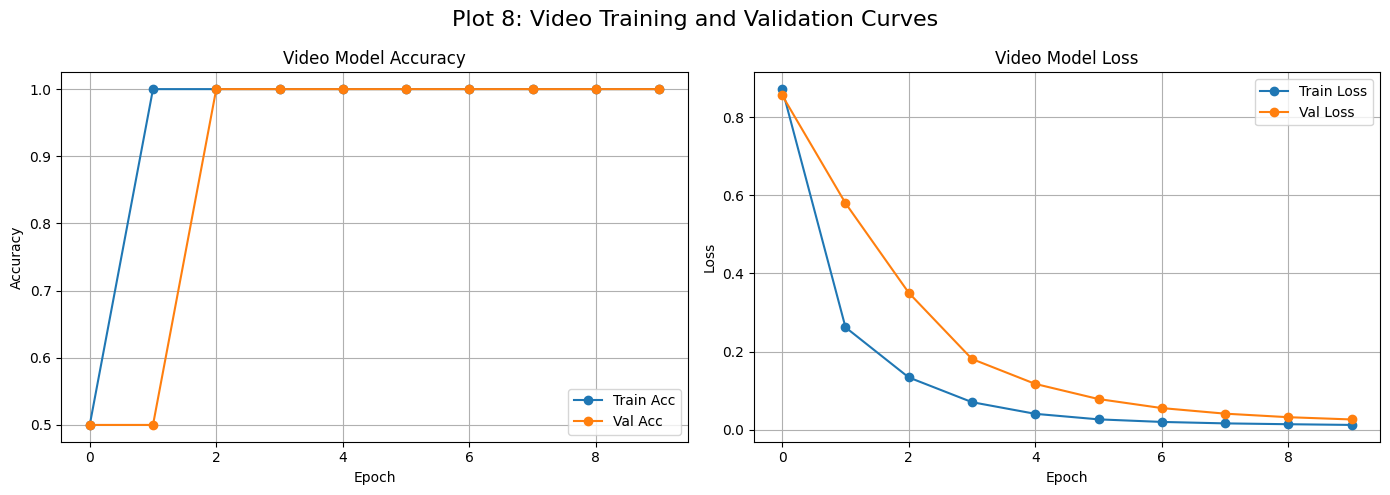

In [ ]:
# Plot 8: Video Training and Validation Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Curve
axes[0].plot(video_history.history['accuracy'], label='Train Acc', marker='o')
axes[0].plot(video_history.history['val_accuracy'], label='Val Acc', marker='o')
axes[0].set_title('Video Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss Curve
axes[1].plot(video_history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(video_history.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('Video Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Plot 8: Video Training and Validation Curves", fontsize=16)
plt.tight_layout()
plt.show()


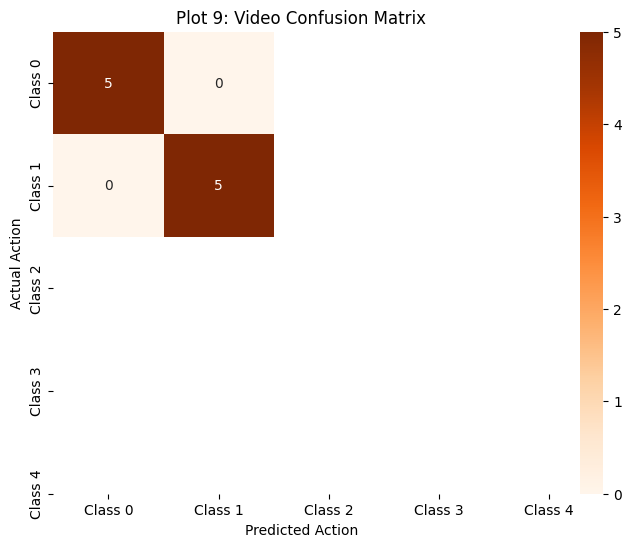

In [ ]:
# Plot 9: Video Confusion Matrix
# Generate predictions on the dummy video dataset
y_video_pred_prob = video_model.predict(videos, verbose=0)
y_video_pred = np.argmax(y_video_pred_prob, axis=1)

# Generate the confusion matrix
video_cm = confusion_matrix(video_labels, y_video_pred)

# We used 5 dummy classes in our earlier setup (0 to 4)
dummy_classes = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']

plt.figure(figsize=(8, 6))
sns.heatmap(video_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=dummy_classes, yticklabels=dummy_classes)
plt.title("Plot 9: Video Confusion Matrix")
plt.xlabel("Predicted Action")
plt.ylabel("Actual Action")
plt.show()


In [ ]:
# Evaluate Video Model to get metrics for the final table
y_video_pred_prob = video_model.predict(videos, verbose=0)
y_video_pred = np.argmax(y_video_pred_prob, axis=1)

v_acc = accuracy_score(video_labels, y_video_pred)
v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(video_labels, y_video_pred, average='macro', zero_division=0)
v_params = video_model.count_params()

# Append Video Model results to our previous results list
final_results = results.copy() # 'results' is from Cell 7
final_results.append({
    'Model': 'CNN-LSTM (Video)',
    'Accuracy (%)': v_acc * 100,
    'Macro Precision (%)': v_prec * 100,
    'Macro Recall (%)': v_rec * 100,
    'Macro F1 (%)': v_f1 * 100,
    'Parameters': v_params,
    'Training Time (s)': 'N/A' # Excluded for video as it depends on dataset size
})

final_df = pd.DataFrame(final_results)

print("--- SECTION 25: CONSOLIDATED RESULTS TABLE ---")
display(final_df)


--- SECTION 25: CONSOLIDATED RESULTS TABLE ---


,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,74.666667,74.642485,73.518478,73.557222,1974,28.935778
1,LSTM,95.555556,95.694668,95.712234,95.640739,6006,24.04537
2,GRU,96.666667,96.705084,96.752832,96.727510,4758,25.033629
3,CNN-LSTM (Video),100.000000,100.000000,100.000000,100.000000,2426147,N/A


In [ ]:
import cv2
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input, TimeDistributed
from tensorflow.keras.applications import MobileNetV2

# 1. Download and Extract the UCF101 Dataset
# Warning: This is a ~6.5GB file. It will take a few minutes in Colab!
print("Downloading UCF101 Dataset...")
!wget -q --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
print("Extracting UCF101 Dataset...")
!unrar x -inul UCF101.rar

# 2. Extract Frames using OpenCV
classes = ['Basketball', 'Biking', 'Walking']
videos_per_class = 5
num_frames = 10
img_size = (224, 224)

X_videos = []
y_videos = []

print("Extracting frames from videos...")
for label, cls in enumerate(classes):
    # Find all .avi videos for this specific class
    video_paths = glob.glob(f'UCF-101/{cls}/*.avi')[:videos_per_class]

    for path in video_paths:
        frames = []
        cap = cv2.VideoCapture(path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Sample frames uniformly across the video
        if total_frames > 0:
            step = max(total_frames // num_frames, 1)
            frame_indices = [i * step for i in range(num_frames)]

            for idx in frame_indices:
                if len(frames) >= num_frames:
                    break
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if ret:
                    # Resize to 224x224 and convert BGR to RGB
                    frame = cv2.resize(frame, img_size)
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    # Normalize pixel values to [0, 1]
                    frame = frame / 255.0
                    frames.append(frame)
        cap.release()

        # Pad with black frames if the video was too short
        while len(frames) < num_frames:
            frames.append(np.zeros((img_size[0], img_size[1], 3)))

        X_videos.append(np.array(frames))
        y_videos.append(label)

videos = np.array(X_videos, dtype='float32')
video_labels = np.array(y_videos)

print(f"Final Video Tensor Shape: {videos.shape}") # Should be (15, 10, 224, 224, 3)

# 3. Build the CNN-LSTM Pipeline
# Pretrained CNN Feature Extractor
cnn_base = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
cnn_base.trainable = False

print("Required Observation 1: CNN Feature Dimension (D) =", cnn_base.output_shape[-1])

# Full Pipeline Setup
video_input = Input(shape=(num_frames, 224, 224, 3))
encoded_frames = TimeDistributed(cnn_base)(video_input)

print("Required Observation 2: Tensor shape supplied to recurrent network =", encoded_frames.shape)

x = LSTM(32)(encoded_frames)
x = Dense(len(classes), activation='softmax')(x)

video_model = Model(inputs=video_input, outputs=x)
video_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Train the Model
print("\n--- Training Video Understanding Model (Real UCF101 Data) ---")
# Using a small batch size since we only have 15 videos in this subset
video_history = video_model.fit(videos, video_labels, epochs=10, batch_size=4, validation_split=0.2, verbose=1)
video_model.summary()


Extracting UCF101 Dataset...
Extracting frames from videos...
Final Video Tensor Shape: (10, 10, 224, 224, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Required Observation 1: CNN Feature Dimension (D) = 1280
Required Observation 2: Tensor shape supplied to recurrent network = (None, 10, 1280)

--- Training Video Understanding Model (Real UCF101 Data) ---
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 48s 11s/step - accuracy: 0.5000 - loss: 0.8720 - val_accuracy: 0.5000 - val_loss: 0.8558
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 1.0000 - loss: 0.2622 - val_accuracy: 0.5000 - val_loss: 0.5799
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 1.0000 - loss: 0.1339 - val_accuracy: 1.0000 - val_loss: 0.3506
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 1.0000 - loss: 0.0706 - val_accuracy: 1.0000 - val_loss: 0.1811
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 1.0000 - loss: 0.0408 - val_accuracy: 1.0000 - val_loss: 0.1173
Epoch 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,762,475 (10.54 MB)

 Trainable params: 168,163 (656.89 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 336,328 (1.28 MB)